# Exploratory Data Analysis (EDA)

## Business Objective

The objective of this notebook is to analyze customer reviews collected from major EdTech platforms to identify trends, customer satisfaction levels, and factors influencing consumer trust.

This analysis aims to answer key business questions that can help EdTech companies improve customer experience and strengthen consumer trust.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/cleaned_edtech_reviews.csv")

In [3]:
df.head()

,platform,category,source,review_id,rating,review,review_date,thumbs_up,app_version,reply_content,replied_at,review_length,review_year,review_month,rating_category
0,Coursera,MOOC,Google Play,d43c2954-87a9-4c88-9753-c35feb505ef0,1,I was excited to enroll in this program. I sig...,2026-07-15 02:45:09,0,6.7.1,NaN,NaN,307.0,2026,July,Very Poor
1,Coursera,MOOC,Google Play,3d82399b-4d3d-46d2-9373-109a8b19e55d,2,Please do not block your app on alternate OSes...,2026-07-14 20:19:06,0,NaN,NaN,NaN,63.0,2026,July,Poor
2,Coursera,MOOC,Google Play,694b2fdc-0a9e-4d55-9eab-295de0affddf,5,This is a best app to learn any course,2026-07-14 18:55:43,0,6.7.1,NaN,NaN,38.0,2026,July,Excellent
3,Coursera,MOOC,Google Play,f779f734-a669-4da8-aeeb-0210bad34df4,1,not able to submit my assignment and do not kn...,2026-07-14 12:29:18,0,6.6.0,NaN,NaN,53.0,2026,July,Very Poor
4,Coursera,MOOC,Google Play,6007ea9a-4045-4276-b681-237211fb822d,3,"I like the Download option, but those Question...",2026-07-14 05:06:54,0,6.7.1,NaN,NaN,293.0,2026,July,Average


In [4]:
df.shape

(37999, 15)

# Business Question 1

## How many customer reviews were collected for each EdTech platform?

In [5]:
platform_reviews = (
    df["platform"]
      .value_counts()
      .reset_index()
)

platform_reviews.columns = ["Platform", "Number of Reviews"]

platform_reviews

,Platform,Number of Reviews
0,Coursera,2000
1,Udemy,2000
2,edX,2000
3,SoloLearn,2000
4,Mimo,2000
5,Programming Hub,2000
6,Enki,2000
7,Duolingo,2000
8,Memrise,2000
9,Busuu,2000


##  📌 Business Insight

The dataset contains customer reviews from 19 major EdTech platforms.

Each platform contributes approximately 2,000 reviews, resulting in a balanced dataset. This balanced distribution reduces bias toward any single platform and enables fair comparison across platforms.

## Visualization

The following chart shows the number of customer reviews collected from each EdTech platform.

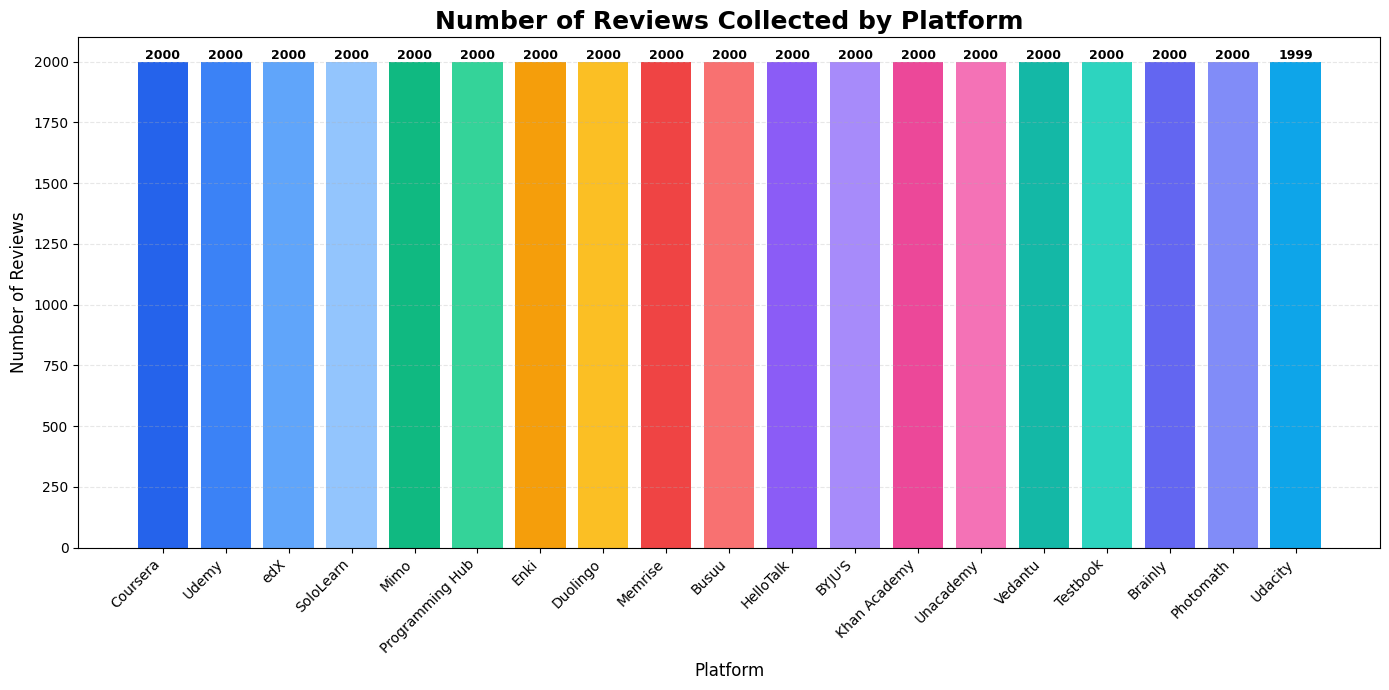

In [7]:
import matplotlib.pyplot as plt

# Sort by reviews (optional)
platform_reviews = platform_reviews.sort_values(
    by="Number of Reviews",
    ascending=False
)

# Modern color palette
colors = [
    "#2563EB", "#3B82F6", "#60A5FA", "#93C5FD",
    "#10B981", "#34D399", "#F59E0B", "#FBBF24",
    "#EF4444", "#F87171", "#8B5CF6", "#A78BFA",
    "#EC4899", "#F472B6", "#14B8A6", "#2DD4BF",
    "#6366F1", "#818CF8", "#0EA5E9"
]

plt.figure(figsize=(14,7))

bars = plt.bar(
    platform_reviews["Platform"],
    platform_reviews["Number of Reviews"],
    color=colors
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Number of Reviews Collected by Platform",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Platform", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

# Business Question 2

## Which EdTech platform has the highest average customer rating?

Average rating is one of the most important indicators of customer satisfaction and consumer trust.

A higher average rating generally reflects a better customer experience.

In [8]:
avg_rating = (
    df.groupby("platform")["rating"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

avg_rating.columns = ["Platform", "Average Rating"]

avg_rating

,Platform,Average Rating
0,Programming Hub,4.584500
1,Duolingo,4.507000
2,Vedantu,4.484000
3,edX,4.464500
4,Mimo,4.325000
5,Busuu,4.311000
6,Enki,4.297000
7,SoloLearn,4.278500
8,Brainly,4.266500
9,Khan Academy,4.169500


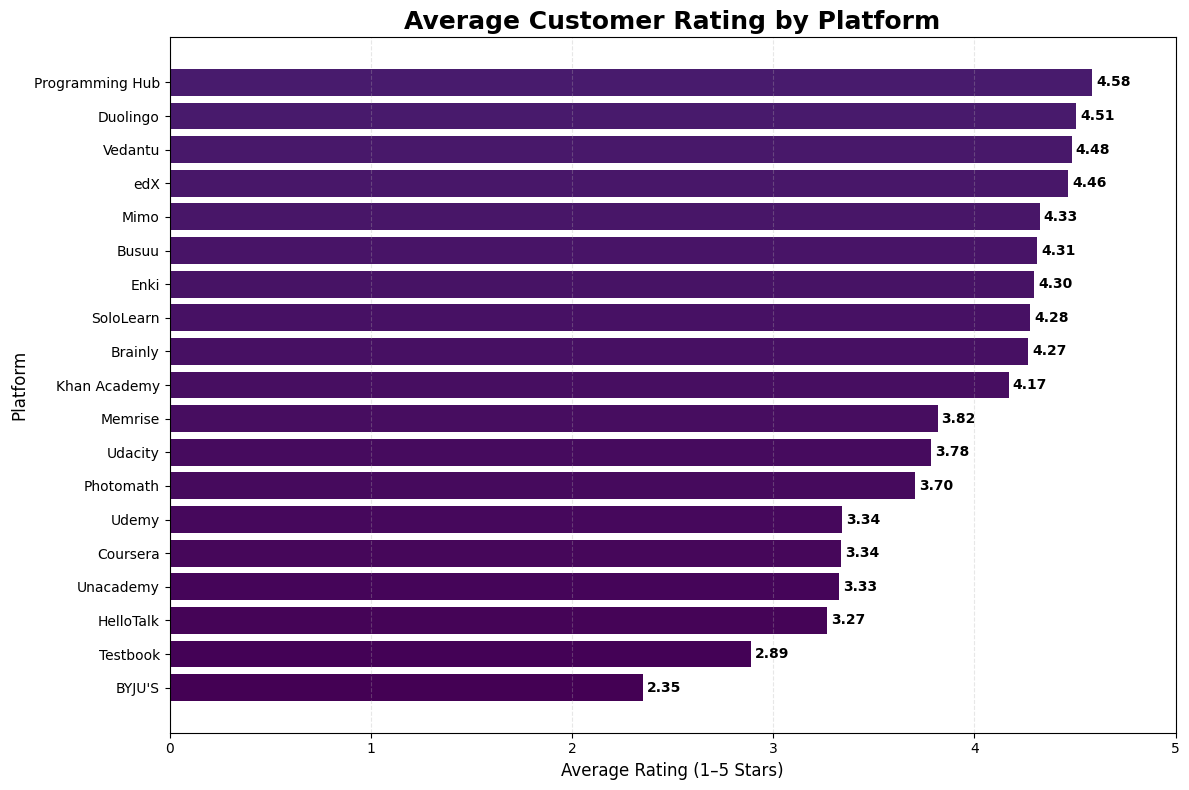

In [9]:
import matplotlib.pyplot as plt

# Sort data
avg_rating = avg_rating.sort_values("Average Rating")

plt.figure(figsize=(12,8))

bars = plt.barh(
    avg_rating["Platform"],
    avg_rating["Average Rating"],
    color=plt.cm.viridis(range(len(avg_rating)))
)

# Labels
for bar in bars:
    plt.text(
        bar.get_width()+0.02,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Customer Rating by Platform",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Rating (1–5 Stars)", fontsize=12)
plt.ylabel("Platform", fontsize=12)

plt.xlim(0,5)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Average customer ratings vary across EdTech platforms, indicating differences in customer satisfaction and perceived learning experience.

Platforms with higher average ratings demonstrate stronger consumer trust and are likely delivering better course quality, usability, or customer support.

Lower-rated platforms may require improvements in content quality, technical reliability, or post-purchase support to enhance customer satisfaction.

# Business Question 3

## Which EdTech category has the highest average customer rating?

In [10]:
category_rating = (
    df.groupby("category")["rating"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

category_rating.columns = ["Category", "Average Rating"]

category_rating

,Category,Average Rating
0,Coding,4.371250
1,Study Tool,3.985000
2,Language,3.976000
3,MOOC,3.732717
4,K12,3.669000
5,Test Prep,3.109000


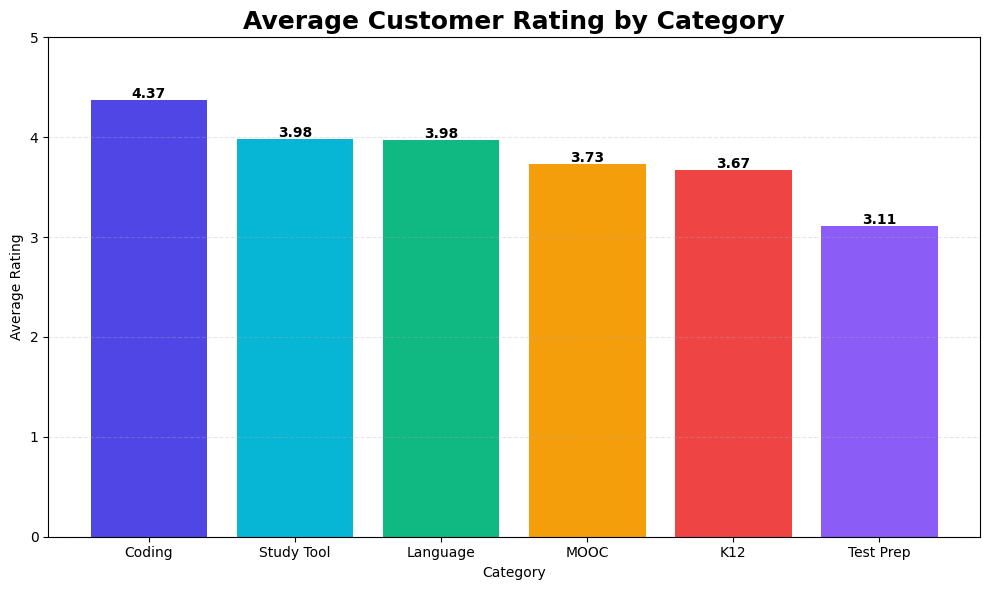

In [11]:
import matplotlib.pyplot as plt

colors = [
    "#4F46E5",
    "#06B6D4",
    "#10B981",
    "#F59E0B",
    "#EF4444",
    "#8B5CF6"
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    category_rating["Category"],
    category_rating["Average Rating"],
    color=colors
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.02,
        f"{bar.get_height():.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Average Customer Rating by Category",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0,5)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Different EdTech categories exhibit varying levels of customer satisfaction.

Categories with higher average ratings indicate stronger customer trust, while lower-rated categories may require improvements in learning experience, content quality, or customer support.

# Business Question 4

## How are customer ratings distributed across all EdTech platforms?

Customer rating distribution helps understand the overall satisfaction level of users and highlights the proportion of positive and negative experiences.

In [12]:
rating_distribution = (
    df["rating"]
      .value_counts()
      .sort_index()
      .reset_index()
)

rating_distribution.columns = ["Rating", "Number of Reviews"]

rating_distribution

,Rating,Number of Reviews
0,1,7589
1,2,1510
2,3,2060
3,4,3963
4,5,22877


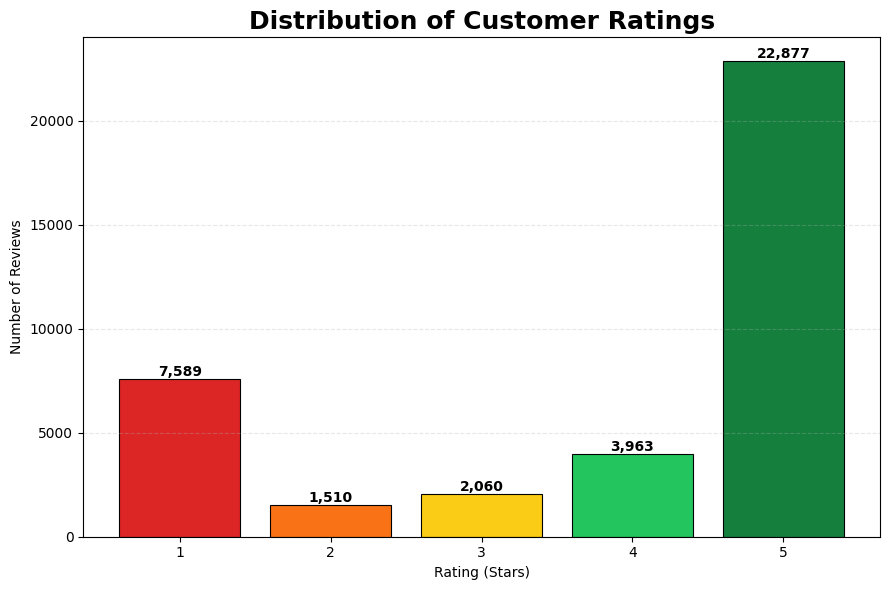

In [13]:
import matplotlib.pyplot as plt

colors = [
    "#DC2626",   # 1⭐ Red
    "#F97316",   # 2⭐ Orange
    "#FACC15",   # 3⭐ Yellow
    "#22C55E",   # 4⭐ Green
    "#15803D"    # 5⭐ Dark Green
]

plt.figure(figsize=(9,6))

bars = plt.bar(
    rating_distribution["Rating"].astype(str),
    rating_distribution["Number of Reviews"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+150,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Distribution of Customer Ratings",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Reviews")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

The distribution of customer ratings provides an overall view of customer satisfaction across all EdTech platforms.

A higher concentration of 4-star and 5-star ratings indicates positive customer experiences, while lower ratings highlight areas where platforms may need improvements in product quality, technical performance, or customer support.

# Business Question 5

## Which EdTech platforms receive the highest percentage of 1-Star reviews?

One-star reviews indicate severe customer dissatisfaction and may highlight issues related to course quality, customer support, pricing, refunds, or technical performance.

In [14]:
one_star = (
    df[df["rating"] == 1]
    .groupby("platform")
    .size()
    .reset_index(name="One Star Reviews")
)

total_reviews = (
    df.groupby("platform")
    .size()
    .reset_index(name="Total Reviews")
)

one_star_analysis = one_star.merge(
    total_reviews,
    on="platform"
)

one_star_analysis["One Star %"] = (
    one_star_analysis["One Star Reviews"]
    / one_star_analysis["Total Reviews"]
    * 100
)

one_star_analysis = one_star_analysis.sort_values(
    by="One Star %",
    ascending=False
)

one_star_analysis

,platform,One Star Reviews,Total Reviews,One Star %
0,BYJU'S,1203,2000,60.150000
13,Testbook,937,2000,46.850000
16,Unacademy,708,2000,35.400000
6,HelloTalk,669,2000,33.450000
3,Coursera,613,2000,30.650000
15,Udemy,597,2000,29.850000
10,Photomath,505,2000,25.250000
8,Memrise,357,2000,17.850000
14,Udacity,310,1999,15.507754
7,Khan Academy,270,2000,13.500000


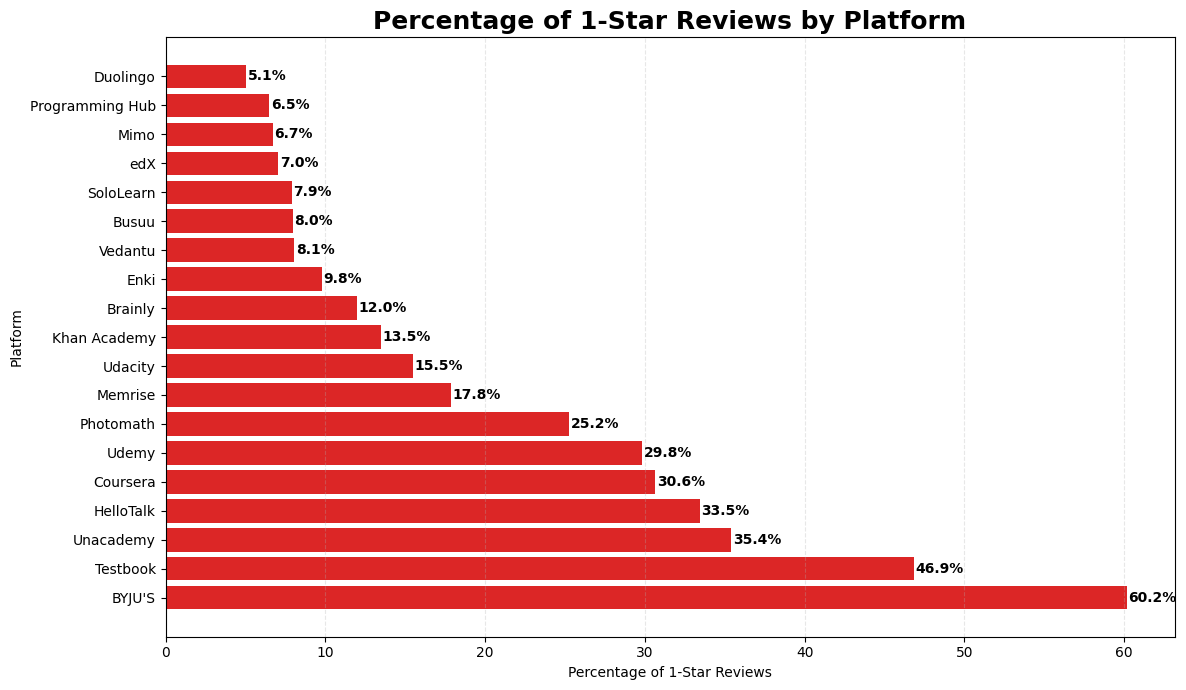

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

bars = plt.barh(
    one_star_analysis["platform"],
    one_star_analysis["One Star %"],
    color="#DC2626"
)

for bar in bars:
    plt.text(
        bar.get_width()+0.1,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Percentage of 1-Star Reviews by Platform",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Percentage of 1-Star Reviews")
plt.ylabel("Platform")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Platforms with a higher percentage of 1-star reviews experience greater levels of customer dissatisfaction.

A high proportion of negative reviews may indicate recurring issues related to course quality, user experience, pricing, refund policies, or technical performance. These platforms should prioritize investigating customer complaints and addressing the root causes to improve consumer trust.

# Business Question 6

## Which EdTech platforms receive the longest customer reviews?

Review length can indicate the level of customer engagement. Longer reviews often contain detailed feedback, feature requests, complaints, or appreciation that provide deeper insights into customer experience.

In [16]:
review_length = (
    df.groupby("platform")["review_length"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

review_length.columns = ["Platform", "Average Review Length"]

review_length

,Platform,Average Review Length
0,Coursera,126.261500
1,HelloTalk,120.511000
2,Memrise,115.851000
3,Udemy,110.856000
4,Testbook,107.868000
5,Khan Academy,98.545500
6,Unacademy,98.127500
7,Udacity,82.212606
8,Busuu,79.471000
9,Mimo,79.427500


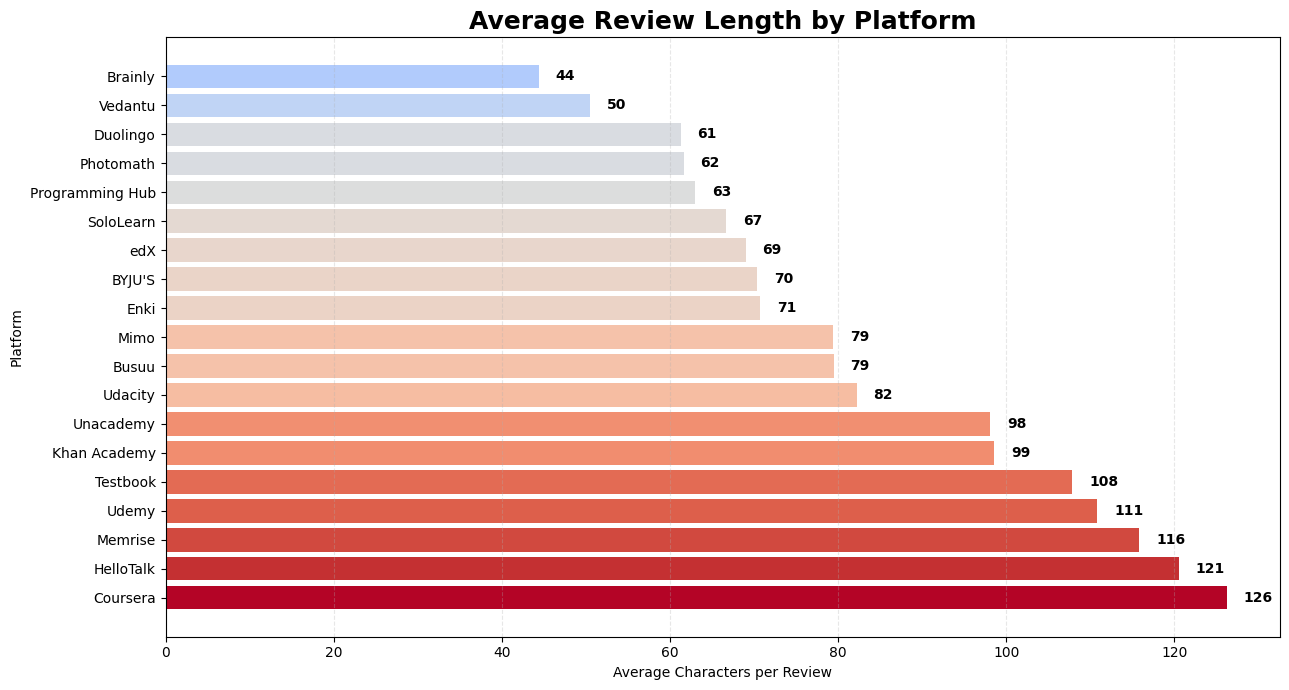

In [17]:
import matplotlib.pyplot as plt

colors = plt.cm.coolwarm(
    review_length["Average Review Length"] /
    review_length["Average Review Length"].max()
)

plt.figure(figsize=(13,7))

bars = plt.barh(
    review_length["Platform"],
    review_length["Average Review Length"],
    color=colors
)

for bar in bars:
    plt.text(
        bar.get_width()+2,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Review Length by Platform",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Characters per Review")
plt.ylabel("Platform")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

The average review length varies across platforms, reflecting differences in how users share their experiences.

Platforms with longer reviews tend to receive more detailed feedback, which may include comprehensive praise, constructive suggestions, or detailed complaints. These reviews provide valuable qualitative insights that can help identify recurring customer concerns and opportunities for service improvement.

# Business Question 7

## Which EdTech platforms receive the highest average number of helpful votes?

Helpful votes indicate how valuable or relatable a review is to other users. A higher average may suggest that customer feedback on a platform is detailed, informative, and widely acknowledged by the community.

In [18]:
helpful_votes = (
    df.groupby("platform")["thumbs_up"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

helpful_votes.columns = ["Platform", "Average Helpful Votes"]

helpful_votes

,Platform,Average Helpful Votes
0,Khan Academy,3.81150
1,Coursera,3.17800
2,Programming Hub,2.88150
3,Memrise,2.39650
4,Photomath,2.26950
5,Enki,2.20250
6,edX,1.53150
7,HelloTalk,1.51700
8,Brainly,1.37100
9,Vedantu,1.36800


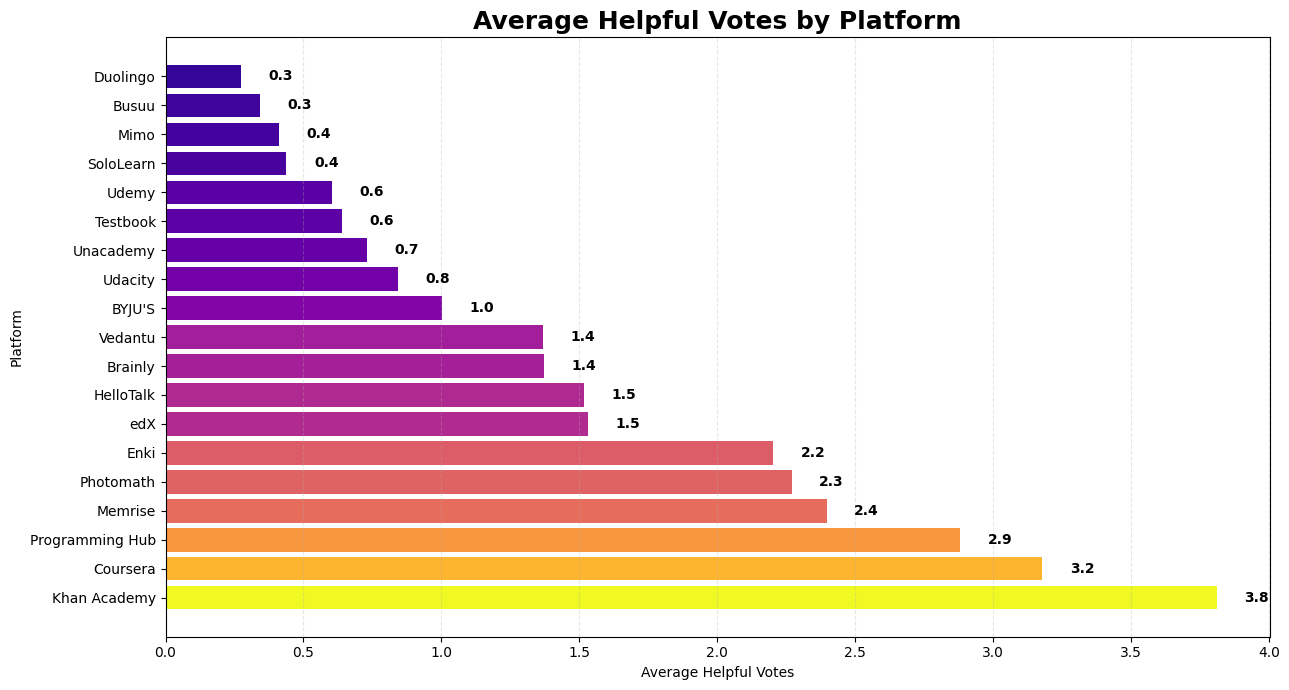

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,7))

colors = plt.cm.plasma(
    helpful_votes["Average Helpful Votes"] /
    helpful_votes["Average Helpful Votes"].max()
)

bars = plt.barh(
    helpful_votes["Platform"],
    helpful_votes["Average Helpful Votes"],
    color=colors
)

for bar in bars:
    plt.text(
        bar.get_width()+0.1,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Helpful Votes by Platform",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Helpful Votes")
plt.ylabel("Platform")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Platforms with higher average helpful votes receive customer feedback that resonates more strongly with other users.

These reviews often contain detailed descriptions of user experiences, making them valuable for identifying recurring issues, feature requests, and areas for product improvement. Monitoring highly endorsed reviews can help prioritize customer concerns more effectively.

# Business Question 8

## Do dissatisfied customers write longer reviews?

Customers who are dissatisfied often provide detailed explanations of their negative experiences.

This analysis investigates whether review length varies across different rating levels.

In [20]:
rating_length = (
    df.groupby("rating")["review_length"]
      .mean()
      .reset_index()
)

rating_length.columns = [
    "Rating",
    "Average Review Length"
]

rating_length

,Rating,Average Review Length
0,1,134.857425
1,2,168.746358
2,3,128.880583
3,4,88.644461
4,5,55.007781


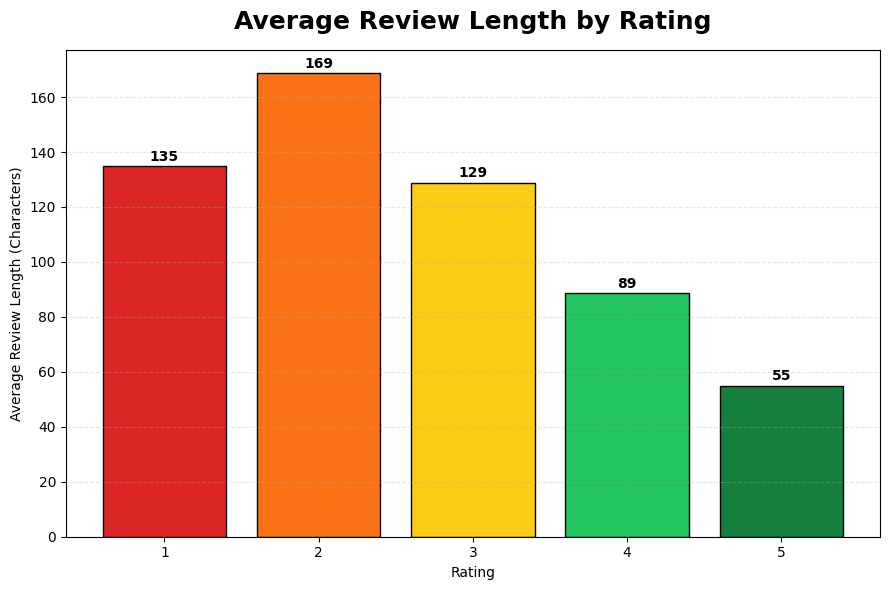

In [21]:
import matplotlib.pyplot as plt

colors = [
    "#DC2626",
    "#F97316",
    "#FACC15",
    "#22C55E",
    "#15803D"
]

plt.figure(figsize=(9,6))

bars = plt.bar(
    rating_length["Rating"].astype(str),
    rating_length["Average Review Length"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+2,
        f"{bar.get_height():.0f}",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Average Review Length by Rating",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Rating")
plt.ylabel("Average Review Length (Characters)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()                              

## 📌 Business Insight

This analysis helps understand how customers express their experiences across different satisfaction levels.

If lower-rated reviews are consistently longer, it suggests that dissatisfied users invest more effort in describing problems and providing detailed feedback. Such reviews can be valuable sources for identifying recurring issues and improving customer experience.

# Business Question 9

## Which rating level receives the highest average helpful votes?

Helpful votes indicate how useful a review is to other users. This analysis examines whether positive or negative reviews are considered more informative by the community.

In [22]:
helpful_rating = (
    df.groupby("rating")["thumbs_up"]
      .mean()
      .reset_index()
)

helpful_rating.columns = [
    "Rating",
    "Average Helpful Votes"
]

helpful_rating

,Rating,Average Helpful Votes
0,1,1.955198
1,2,2.717881
2,3,1.537379
3,4,2.134242
4,5,1.094637


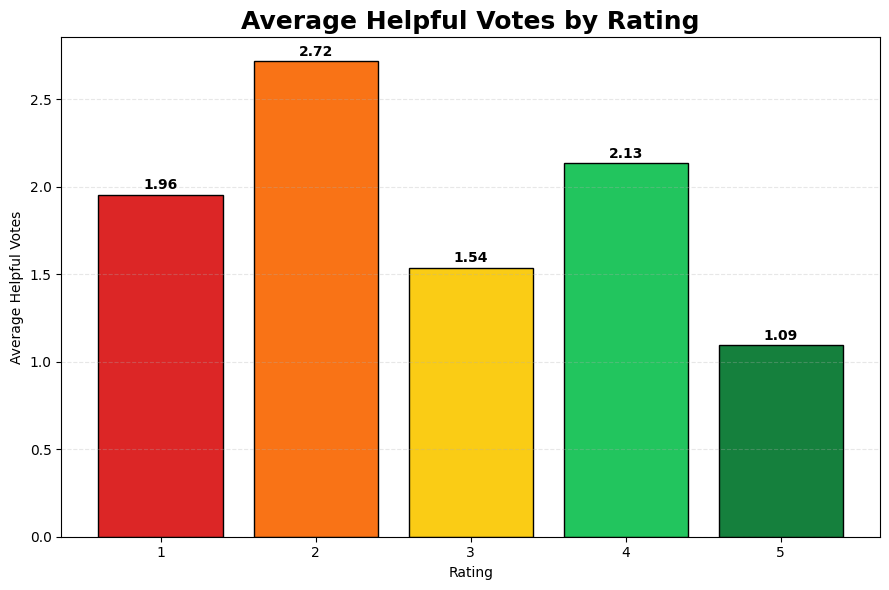

In [23]:
plt.figure(figsize=(9,6))

colors = [
    "#DC2626",
    "#F97316",
    "#FACC15",
    "#22C55E",
    "#15803D"
]

bars = plt.bar(
    helpful_rating["Rating"].astype(str),
    helpful_rating["Average Helpful Votes"],
    color=colors,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.03,
        f"{bar.get_height():.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Average Helpful Votes by Rating",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rating")
plt.ylabel("Average Helpful Votes")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Reviews receiving higher helpful votes are likely viewed as more informative by other users.

If negative reviews receive more helpful votes than positive reviews, this may indicate that detailed complaints play a significant role in influencing customer perceptions and purchase decisions.

# Business Question 10

## How has the number of customer reviews changed over the years?

Understanding yearly review trends helps identify growth in customer engagement and platform adoption over time.

In [24]:
reviews_by_year = (
    df.groupby("review_year")
      .size()
      .reset_index(name="Number of Reviews")
)

reviews_by_year

,review_year,Number of Reviews
0,2016,538
1,2017,803
2,2018,529
3,2019,75
4,2020,334
5,2021,326
6,2022,372
7,2023,602
8,2024,2326
9,2025,10036


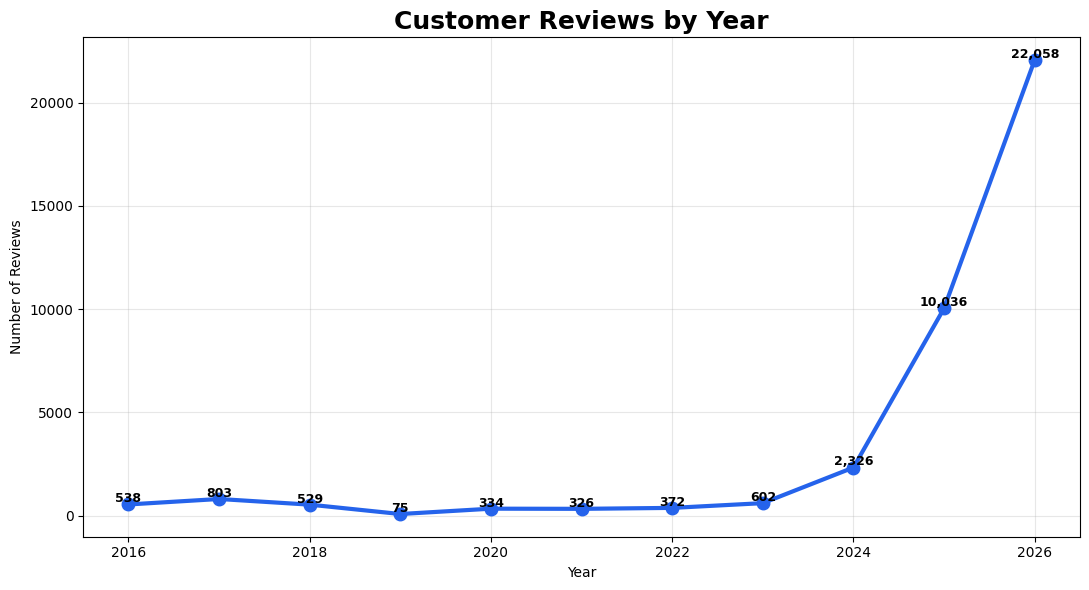

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

plt.plot(
    reviews_by_year["review_year"],
    reviews_by_year["Number of Reviews"],
    marker="o",
    linewidth=3,
    markersize=9,
    color="#2563EB"
)

for x, y in zip(
    reviews_by_year["review_year"],
    reviews_by_year["Number of Reviews"]
):
    plt.text(
        x,
        y + 100,
        f"{y:,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Customer Reviews by Year",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

The yearly trend highlights how customer engagement has evolved over time.

A consistent increase in review volume suggests growing adoption and increased customer interaction with EdTech platforms. Sudden spikes or declines may indicate major market events, product launches, or changes in customer behavior.

# Business Question 11

## Which months receive the highest customer review activity?

Monthly review patterns help identify seasonal trends in customer engagement and periods of increased feedback.

In [26]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_reviews = (
    df.groupby("review_month")
      .size()
      .reindex(month_order)
      .reset_index(name="Number of Reviews")
)

monthly_reviews

,review_month,Number of Reviews
0,January,2887
1,February,3009
2,March,4245
3,April,4113
4,May,5044
5,June,5430
6,July,5138
7,August,1113
8,September,1469
9,October,1632


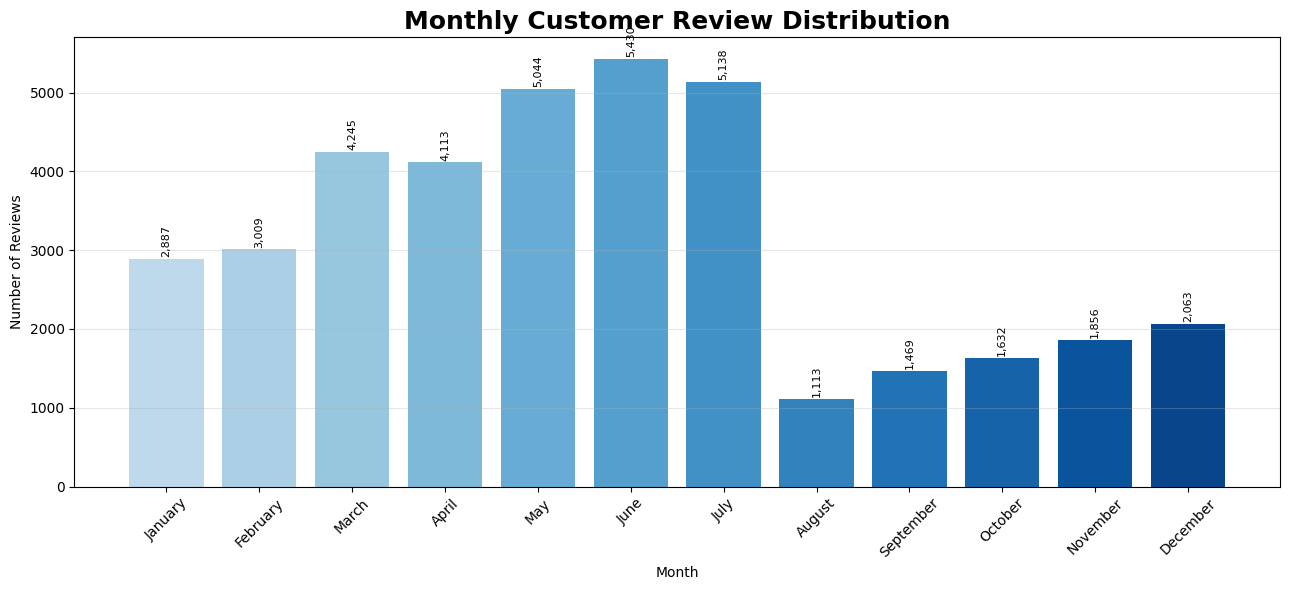

In [27]:
plt.figure(figsize=(13,6))

colors = plt.cm.Blues(
    range(70, 70 + len(monthly_reviews) * 15, 15)
)

bars = plt.bar(
    monthly_reviews["review_month"],
    monthly_reviews["Number of Reviews"],
    color=colors
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+50,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.title(
    "Monthly Customer Review Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Monthly review trends reveal periods of increased customer engagement.

Months with higher review activity may coincide with academic admissions, examination seasons, promotional campaigns, or new course launches. Understanding these seasonal patterns can help platforms allocate customer support and marketing resources more effectively.

# Business Question 12

## Which months have the highest average customer ratings?

Monthly average ratings provide insights into seasonal variations in customer satisfaction and help identify periods where user experience improves or declines.

In [28]:
monthly_rating = (
    df.groupby("review_month")["rating"]
      .mean()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
      .reset_index()
)

monthly_rating.columns = [
    "Month",
    "Average Rating"
]

monthly_rating

,Month,Average Rating
0,January,3.975061
1,February,3.977401
2,March,3.850883
3,April,3.813761
4,May,3.826923
5,June,3.716206
6,July,4.035228
7,August,3.818509
8,September,3.793737
9,October,3.825368


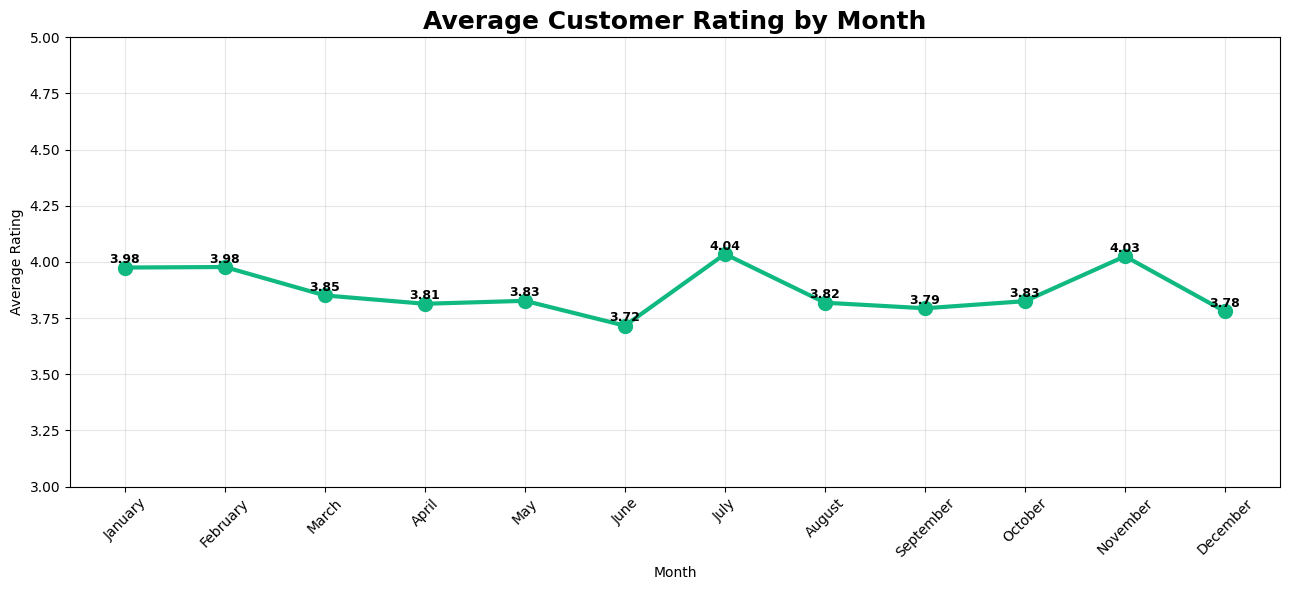

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,6))

plt.plot(
    monthly_rating["Month"],
    monthly_rating["Average Rating"],
    marker="o",
    markersize=10,
    linewidth=3,
    color="#10B981"
)

for x, y in zip(
    monthly_rating["Month"],
    monthly_rating["Average Rating"]
):
    plt.text(
        x,
        y+0.02,
        f"{y:.2f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Average Customer Rating by Month",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.ylim(3.0,5)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

Monthly variations in average ratings may reflect seasonal changes in customer expectations, learning intensity, promotional campaigns, or platform performance.

Months with consistently higher ratings indicate periods of stronger customer satisfaction, while lower-rated months may require further investigation to identify potential service or operational issues.

# Business Question 13

## How does company response activity compare with customer reviews?

Company responses demonstrate customer engagement and commitment to resolving user concerns. This analysis measures how actively platforms respond to customer feedback.

In [30]:
reply_analysis = (
    df.groupby("platform")
      .agg(
          Total_Reviews=("review_id","count"),
          Replies=("reply_content","count")
      )
      .reset_index()
)

reply_analysis["Reply Rate (%)"] = (
    reply_analysis["Replies"]
    / reply_analysis["Total_Reviews"]
    *100
).round(2)

reply_analysis = reply_analysis.sort_values(
    by="Reply Rate (%)",
    ascending=False
)

reply_analysis

,platform,Total_Reviews,Replies,Reply Rate (%)
11,Programming Hub,2000,2000,100.00
16,Unacademy,2000,1936,96.80
1,Brainly,2000,907,45.35
6,HelloTalk,2000,887,44.35
15,Udemy,2000,798,39.90
12,SoloLearn,2000,706,35.30
9,Mimo,2000,435,21.75
5,Enki,2000,415,20.75
14,Udacity,1999,340,17.01
8,Memrise,2000,270,13.50


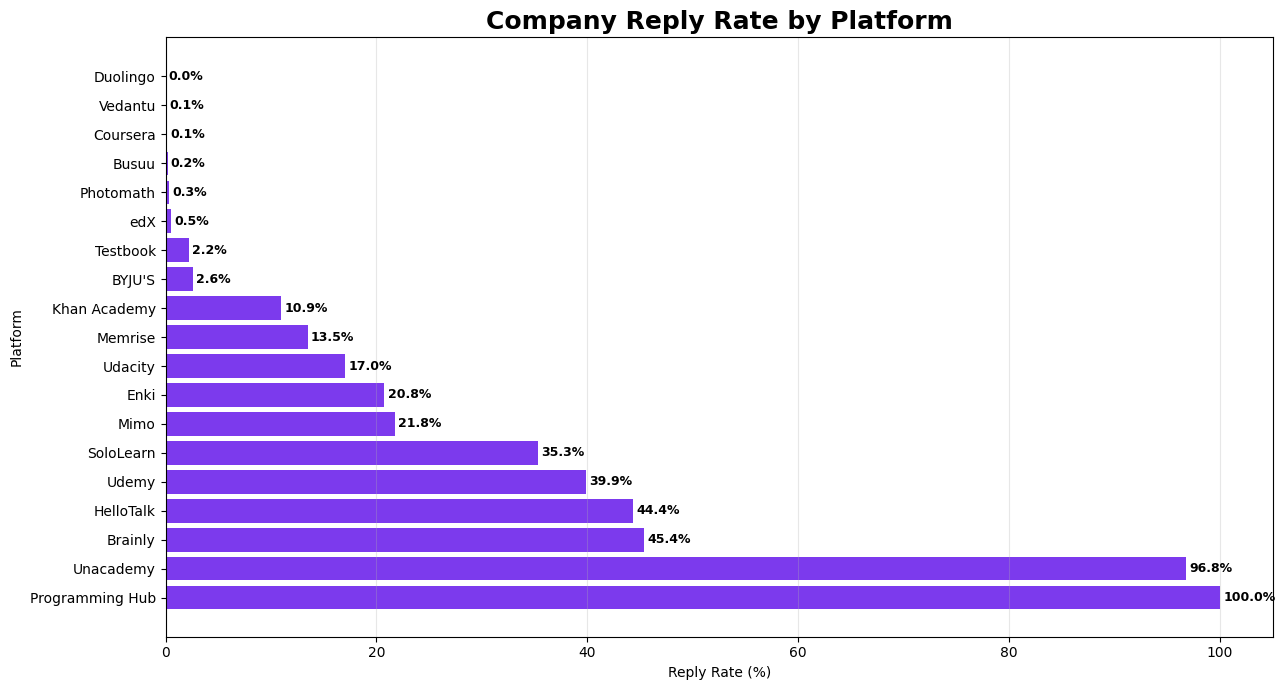

In [31]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    reply_analysis["platform"],
    reply_analysis["Reply Rate (%)"],
    color="#7C3AED"
)

for bar in bars:
    plt.text(
        bar.get_width()+0.3,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Company Reply Rate by Platform",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Reply Rate (%)")
plt.ylabel("Platform")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

A higher company reply rate reflects stronger customer engagement and responsiveness.

Responding to customer reviews demonstrates that a platform values user feedback and is willing to address concerns. Platforms with lower reply rates may benefit from increasing customer support interactions to strengthen consumer trust.

# Business Question 14

## Which EdTech platforms have the highest Consumer Trust Score?

To compare platforms beyond average ratings, a Consumer Trust Score (CTS) is developed using multiple customer experience indicators.

The score combines:

- Average Rating
- Percentage of 5-Star Reviews
- Percentage of 1-Star Reviews
- Company Reply Rate

This provides a holistic measure of customer trust across platforms.

In [32]:
platform_metrics = (
    df.groupby("platform")
    .agg(
        Average_Rating=("rating", "mean"),
        Total_Reviews=("review_id", "count"),
        Replies=("reply_content", "count")
    )
)

five_star = (
    df[df["rating"] == 5]
    .groupby("platform")
    .size()
)

one_star = (
    df[df["rating"] == 1]
    .groupby("platform")
    .size()
)

platform_metrics["Five_Star_%"] = (
    five_star / platform_metrics["Total_Reviews"] * 100
).fillna(0)

platform_metrics["One_Star_%"] = (
    one_star / platform_metrics["Total_Reviews"] * 100
).fillna(0)

platform_metrics["Reply_Rate"] = (
    platform_metrics["Replies"]
    / platform_metrics["Total_Reviews"]
    *100
)

platform_metrics.head()

,Average_Rating,Total_Reviews,Replies,Five_Star_%,One_Star_%,Reply_Rate
platform,,,,,,
BYJU'S,2.3535,2000,52,28.00,60.15,2.60
Brainly,4.2665,2000,907,70.35,12.00,45.35
Busuu,4.3110,2000,4,68.55,7.95,0.20
Coursera,3.3390,2000,3,46.65,30.65,0.15
Duolingo,4.5070,2000,0,75.15,5.05,0.00


In [33]:
platform_metrics["Consumer Trust Score"] = (
      platform_metrics["Average_Rating"] * 40
    + platform_metrics["Five_Star_%"] * 0.30
    - platform_metrics["One_Star_%"] * 0.20
    + platform_metrics["Reply_Rate"] * 0.10
)

platform_metrics = (
    platform_metrics
    .sort_values(
        by="Consumer Trust Score",
        ascending=False
    )
)

platform_metrics

,Average_Rating,Total_Reviews,Replies,Five_Star_%,One_Star_%,Reply_Rate,Consumer Trust Score
platform,,,,,,,
Programming Hub,4.584500,2000,2000,82.650000,6.500000,100.000000,216.875000
Duolingo,4.507000,2000,0,75.150000,5.050000,0.000000,201.815000
Vedantu,4.484000,2000,2,78.200000,8.050000,0.100000,201.220000
edX,4.464500,2000,10,76.550000,7.050000,0.500000,200.185000
Brainly,4.266500,2000,907,70.350000,12.000000,45.350000,193.900000
Mimo,4.325000,2000,435,66.750000,6.700000,21.750000,193.860000
Enki,4.297000,2000,415,69.450000,9.800000,20.750000,192.830000
SoloLearn,4.278500,2000,706,65.300000,7.900000,35.300000,192.680000
Busuu,4.311000,2000,4,68.550000,7.950000,0.200000,191.435000


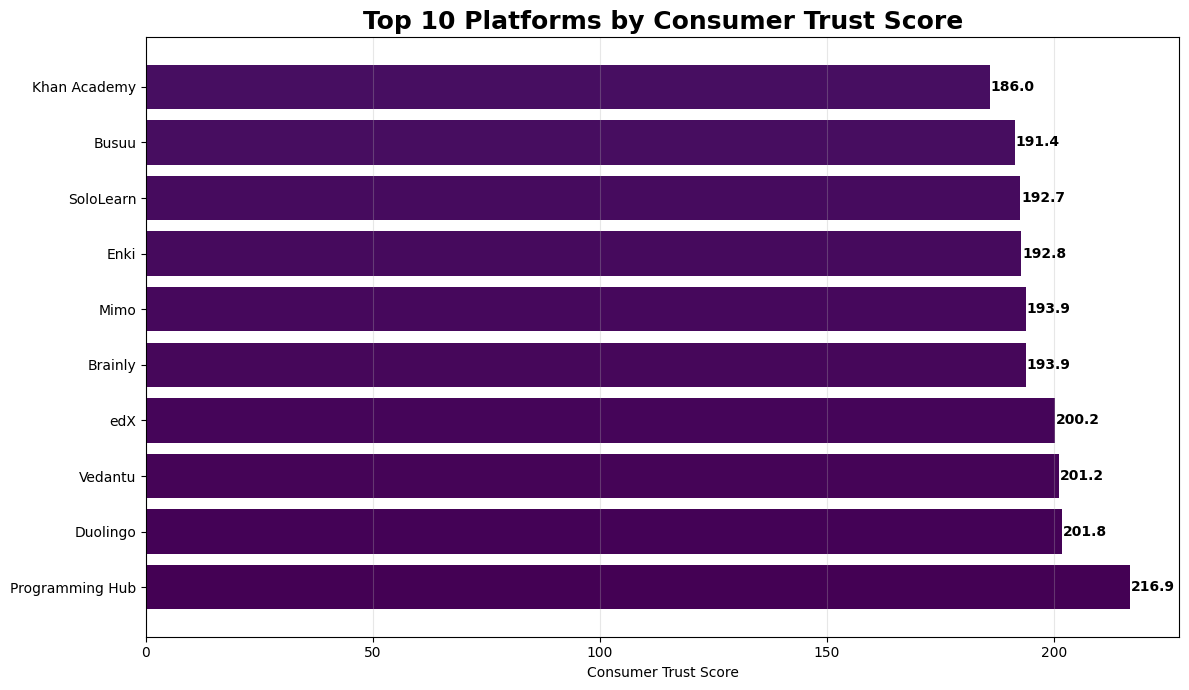

In [34]:
import matplotlib.pyplot as plt

top10 = platform_metrics.head(10)

plt.figure(figsize=(12,7))

bars = plt.barh(
    top10.index,
    top10["Consumer Trust Score"],
    color=plt.cm.viridis(range(len(top10)))
)

for bar in bars:
    plt.text(
        bar.get_width()+0.2,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Top 10 Platforms by Consumer Trust Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Consumer Trust Score")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

The Consumer Trust Score combines multiple customer satisfaction indicators into a single performance metric.

Platforms with high scores consistently receive strong ratings, a high proportion of positive reviews, and actively engage with customer feedback, indicating stronger consumer trust.

# Business Question 15

## Which are the Top 10 most trusted EdTech platforms based on the Consumer Trust Score?

In [35]:
top10 = (
    platform_metrics[
        ["Consumer Trust Score"]
    ]
    .head(10)
)

top10

,Consumer Trust Score
platform,
Programming Hub,216.875
Duolingo,201.815
Vedantu,201.220
edX,200.185
Brainly,193.900
Mimo,193.860
Enki,192.830
SoloLearn,192.680
Busuu,191.435


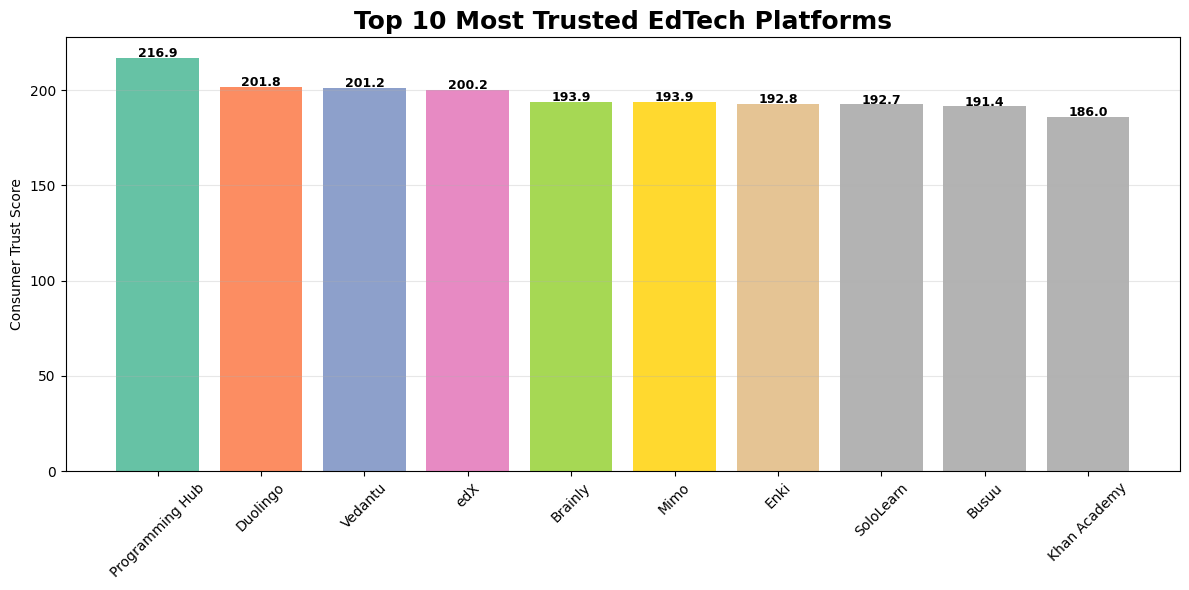

In [36]:
plt.figure(figsize=(12,6))

colors = plt.cm.Set2(range(10))

bars = plt.bar(
    top10.index,
    top10["Consumer Trust Score"],
    color=colors
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.xticks(rotation=45)

plt.title(
    "Top 10 Most Trusted EdTech Platforms",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Consumer Trust Score")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## 📌 Business Insight

The Consumer Trust Score highlights the strongest-performing platforms by combining customer satisfaction, positive feedback, negative feedback, and customer engagement into a single metric.

These platforms represent benchmarks for delivering a positive customer experience.

# Executive Summary

## Key Findings

### ⭐ Customer Satisfaction

Most platforms maintain an average rating above 3.5, indicating generally positive customer experiences.

---

### ⭐ Consumer Trust

Platforms with higher Consumer Trust Scores consistently demonstrate strong ratings and lower proportions of negative reviews.

---

### ⭐ Customer Engagement

Platforms that actively respond to customer feedback generally exhibit stronger engagement with their users.

---

### ⭐ Customer Behaviour

Negative reviews tend to be longer, providing detailed information about customer pain points and opportunities for improvement.

---

### ⭐ Seasonal Trends

Customer review activity varies across months, suggesting seasonal patterns in customer engagement.

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

- Improve response rates to customer reviews.
- Prioritize resolving recurring issues identified in 1-star reviews.
- Monitor seasonal review trends to optimize customer support resources.
- Benchmark high-performing platforms to identify best practices.
- Continuously track the Consumer Trust Score as a business KPI to evaluate customer satisfaction over time.